## EDA PART

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## Dataset Loading & Basic Information

In [2]:
df = pd.read_csv(r"E:\AirPulse AI\Files\data\globalAirQuality.csv")

In [3]:
df.head() # Top 10 entries

,timestamp,country,city,latitude,longitude,pm25,pm10,no2,so2,o3,co,aqi,temperature,humidity,wind_speed
0,2025-11-04 18:25:17.554219,US,New York,40.713,-74.006,50.295,108.938,27.998,6.539,52.568,1.096,108,18.504,70.168,3.725
1,2025-11-04 19:25:17.554219,US,New York,40.713,-74.006,32.083,63.043,36.120,4.021,43.536,1.075,90,5.838,80.088,8.969
2,2025-11-04 20:25:17.554219,US,New York,40.713,-74.006,42.250,82.553,26.935,9.538,23.320,0.977,84,31.833,62.783,9.650
3,2025-11-04 21:25:17.554219,US,New York,40.713,-74.006,30.403,79.951,63.536,7.609,31.369,0.230,158,23.140,89.153,8.956
4,2025-11-04 22:25:17.554219,US,New York,40.713,-74.006,21.083,66.423,38.997,6.919,45.615,1.085,97,13.632,76.499,4.017


In [4]:
df.tail() # Last ten entries

,timestamp,country,city,latitude,longitude,pm25,pm10,no2,so2,o3,co,aqi,temperature,humidity,wind_speed
17995,2025-11-19 13:25:17.554219,CH,Zurich,47.377,8.542,27.899,74.179,41.474,6.677,50.869,1.028,103,7.079,52.443,7.452
17996,2025-11-19 14:25:17.554219,CH,Zurich,47.377,8.542,2.950,47.988,42.235,2.821,35.551,0.644,105,28.734,85.678,4.496
17997,2025-11-19 15:25:17.554219,CH,Zurich,47.377,8.542,61.347,72.908,46.976,5.763,66.492,0.947,122,21.951,72.311,9.660
17998,2025-11-19 16:25:17.554219,CH,Zurich,47.377,8.542,40.722,95.152,32.957,5.524,53.193,0.868,95,24.042,31.880,2.642
17999,2025-11-19 17:25:17.554219,CH,Zurich,47.377,8.542,25.830,30.411,35.317,4.336,66.246,0.848,88,8.529,59.104,4.403


In [5]:
df.shape # Shape of the dataset (rows and columns)

(18000, 15)

In [6]:
df.columns # Showing all columns

Index(['timestamp', 'country', 'city', 'latitude', 'longitude', 'pm25', 'pm10',
       'no2', 'so2', 'o3', 'co', 'aqi', 'temperature', 'humidity',
       'wind_speed'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   timestamp    18000 non-null  object 
 1   country      18000 non-null  object 
 2   city         18000 non-null  object 
 3   latitude     18000 non-null  float64
 4   longitude    18000 non-null  float64
 5   pm25         18000 non-null  float64
 6   pm10         18000 non-null  float64
 7   no2          18000 non-null  float64
 8   so2          18000 non-null  float64
 9   o3           18000 non-null  float64
 10  co           18000 non-null  float64
 11  aqi          18000 non-null  int64  
 12  temperature  18000 non-null  float64
 13  humidity     18000 non-null  float64
 14  wind_speed   18000 non-null  float64
dtypes: float64(11), int64(1), object(3)
memory usage: 2.1+ MB


In [8]:
df.describe() # Statistical summary of the dataset

,latitude,longitude,pm25,pm10,no2,so2,o3,co,aqi,temperature,humidity,wind_speed
count,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000
mean,23.065980,37.655560,40.369131,70.152228,32.055176,6.035508,48.065100,0.800595,104.645556,21.510251,57.714351,5.283910
std,26.156536,78.600701,17.647450,24.999440,13.820680,2.454790,14.950849,0.250254,25.616070,9.509444,18.844908,2.741712
min,-37.814000,-123.121000,0.025000,0.061000,0.013000,0.003000,0.114000,0.000000,16.000000,5.000000,25.002000,0.500000
25%,12.972000,2.352000,27.904500,53.125500,22.362500,4.360750,38.028500,0.633000,87.000000,13.357750,41.320000,2.937000
50%,29.232000,42.146000,40.286500,69.961000,32.019500,6.026000,48.142000,0.800500,103.000000,21.455500,57.847000,5.297000
75%,41.008000,103.820000,52.436250,87.256500,41.364250,7.715250,58.258500,0.969000,121.000000,29.688250,74.234750,7.662000
max,60.170000,174.763000,115.683000,161.810000,90.019000,16.559000,103.016000,1.832000,231.000000,37.998000,89.997000,9.999000


## Missing values analysis

In [9]:
df.isnull().sum()

timestamp      0
country        0
city           0
latitude       0
longitude      0
pm25           0
pm10           0
no2            0
so2            0
o3             0
co             0
aqi            0
temperature    0
humidity       0
wind_speed     0
dtype: int64

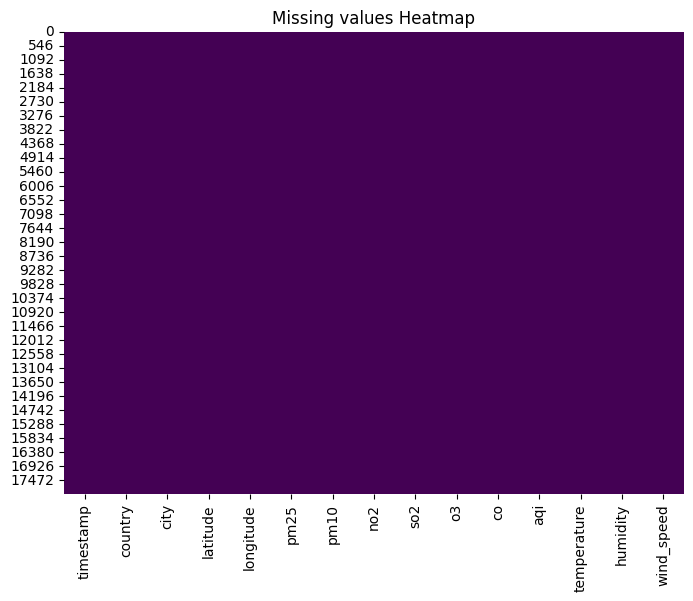

In [10]:
# Via a diagram
plt.figure(figsize=(8,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing values Heatmap")
plt.show()

In [11]:
duplicates = df.duplicated().sum()
print("Duplicated rows: ", duplicates)

# No duplicate records were found in the dataset.Hence, no duplicate removal was required.

Duplicated rows:  0


In [12]:
df.head()

,timestamp,country,city,latitude,longitude,pm25,pm10,no2,so2,o3,co,aqi,temperature,humidity,wind_speed
0,2025-11-04 18:25:17.554219,US,New York,40.713,-74.006,50.295,108.938,27.998,6.539,52.568,1.096,108,18.504,70.168,3.725
1,2025-11-04 19:25:17.554219,US,New York,40.713,-74.006,32.083,63.043,36.120,4.021,43.536,1.075,90,5.838,80.088,8.969
2,2025-11-04 20:25:17.554219,US,New York,40.713,-74.006,42.250,82.553,26.935,9.538,23.320,0.977,84,31.833,62.783,9.650
3,2025-11-04 21:25:17.554219,US,New York,40.713,-74.006,30.403,79.951,63.536,7.609,31.369,0.230,158,23.140,89.153,8.956
4,2025-11-04 22:25:17.554219,US,New York,40.713,-74.006,21.083,66.423,38.997,6.919,45.615,1.085,97,13.632,76.499,4.017


## Fixing Country name

In [13]:
country_mapping = {
    'US': 'United States',
    'GB': 'United Kingdom',
    'FR': 'France',
    'DE': 'Germany',
    'ES': 'Spain',
    'IT': 'Italy',
    'CA': 'Canada',
    'MX': 'Mexico',
    'BR': 'Brazil',
    'AR': 'Argentina',
    'ZA': 'South Africa',
    'EG': 'Egypt',
    'KE': 'Kenya',
    'NG': 'Nigeria',
    'AE': 'United Arab Emirates',
    'SA': 'Saudi Arabia',
    'QA': 'Qatar',
    'IN': 'India',
    'JP': 'Japan',
    'KR': 'South Korea',
    'CN': 'China',
    'HK': 'Hong Kong',
    'SG': 'Singapore',
    'TH': 'Thailand',
    'MY': 'Malaysia',
    'ID': 'Indonesia',
    'AU': 'Australia',
    'NZ': 'New Zealand',
    'RU': 'Russia',
    'TR': 'Turkey',
    'IR': 'Iran',
    'PK': 'Pakistan',
    'PH': 'Philippines',
    'VN': 'Vietnam',
    'PL': 'Poland',
    'SE': 'Sweden',
    'FI': 'Finland',
    'CH': 'Switzerland'
}

In [14]:
df["country"] = df["country"].map(country_mapping)

In [15]:
df['country'].isnull().sum()

0

In [16]:
df['country'].unique()

array(['United States', 'United Kingdom', 'France', 'Germany', 'Spain',
       'Italy', 'Canada', 'Mexico', 'Brazil', 'Argentina', 'South Africa',
       'Egypt', 'Kenya', 'Nigeria', 'United Arab Emirates',
       'Saudi Arabia', 'Qatar', 'India', 'Japan', 'South Korea', 'China',
       'Hong Kong', 'Singapore', 'Thailand', 'Malaysia', 'Indonesia',
       'Australia', 'New Zealand', 'Russia', 'Turkey', 'Iran', 'Pakistan',
       'Philippines', 'Vietnam', 'Poland', 'Sweden', 'Finland',
       'Switzerland'], dtype=object)

In [17]:
df.head()

,timestamp,country,city,latitude,longitude,pm25,pm10,no2,so2,o3,co,aqi,temperature,humidity,wind_speed
0,2025-11-04 18:25:17.554219,United States,New York,40.713,-74.006,50.295,108.938,27.998,6.539,52.568,1.096,108,18.504,70.168,3.725
1,2025-11-04 19:25:17.554219,United States,New York,40.713,-74.006,32.083,63.043,36.120,4.021,43.536,1.075,90,5.838,80.088,8.969
2,2025-11-04 20:25:17.554219,United States,New York,40.713,-74.006,42.250,82.553,26.935,9.538,23.320,0.977,84,31.833,62.783,9.650
3,2025-11-04 21:25:17.554219,United States,New York,40.713,-74.006,30.403,79.951,63.536,7.609,31.369,0.230,158,23.140,89.153,8.956
4,2025-11-04 22:25:17.554219,United States,New York,40.713,-74.006,21.083,66.423,38.997,6.919,45.615,1.085,97,13.632,76.499,4.017


## Timestamp Feature Engineering

In [18]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [19]:
df["hour"] = df["timestamp"].dt.hour
df["day"] = df["timestamp"].dt.day
df["month"] = df["timestamp"].dt.month
df["weekday"] = df["timestamp"].dt.weekday

In [20]:
df.head()

,timestamp,country,city,latitude,longitude,pm25,pm10,no2,so2,o3,co,aqi,temperature,humidity,wind_speed,hour,day,month,weekday
0,2025-11-04 18:25:17.554219,United States,New York,40.713,-74.006,50.295,108.938,27.998,6.539,52.568,1.096,108,18.504,70.168,3.725,18,4,11,1
1,2025-11-04 19:25:17.554219,United States,New York,40.713,-74.006,32.083,63.043,36.120,4.021,43.536,1.075,90,5.838,80.088,8.969,19,4,11,1
2,2025-11-04 20:25:17.554219,United States,New York,40.713,-74.006,42.250,82.553,26.935,9.538,23.320,0.977,84,31.833,62.783,9.650,20,4,11,1
3,2025-11-04 21:25:17.554219,United States,New York,40.713,-74.006,30.403,79.951,63.536,7.609,31.369,0.230,158,23.140,89.153,8.956,21,4,11,1
4,2025-11-04 22:25:17.554219,United States,New York,40.713,-74.006,21.083,66.423,38.997,6.919,45.615,1.085,97,13.632,76.499,4.017,22,4,11,1


## Univariate Analysis

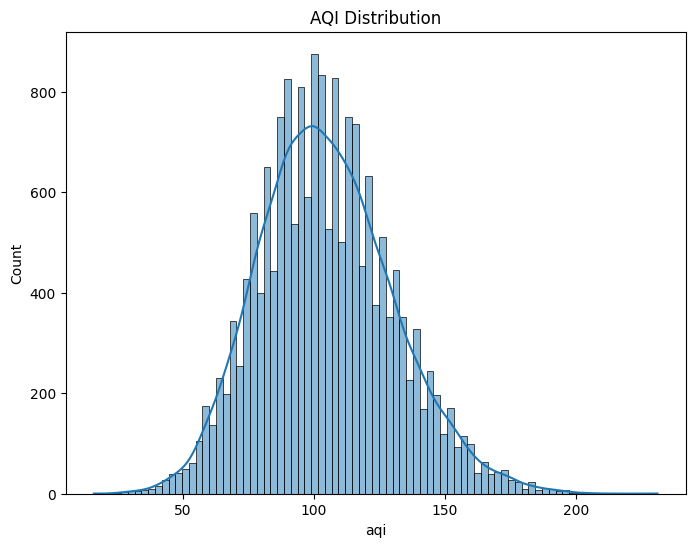

In [21]:
# AQI Distribution
plt.figure(figsize=(8,6))
sns.histplot(df["aqi"], kde=True)
plt.title("AQI Distribution")
plt.show()

In [22]:
df.head(2)

,timestamp,country,city,latitude,longitude,pm25,pm10,no2,so2,o3,co,aqi,temperature,humidity,wind_speed,hour,day,month,weekday
0,2025-11-04 18:25:17.554219,United States,New York,40.713,-74.006,50.295,108.938,27.998,6.539,52.568,1.096,108,18.504,70.168,3.725,18,4,11,1
1,2025-11-04 19:25:17.554219,United States,New York,40.713,-74.006,32.083,63.043,36.120,4.021,43.536,1.075,90,5.838,80.088,8.969,19,4,11,1


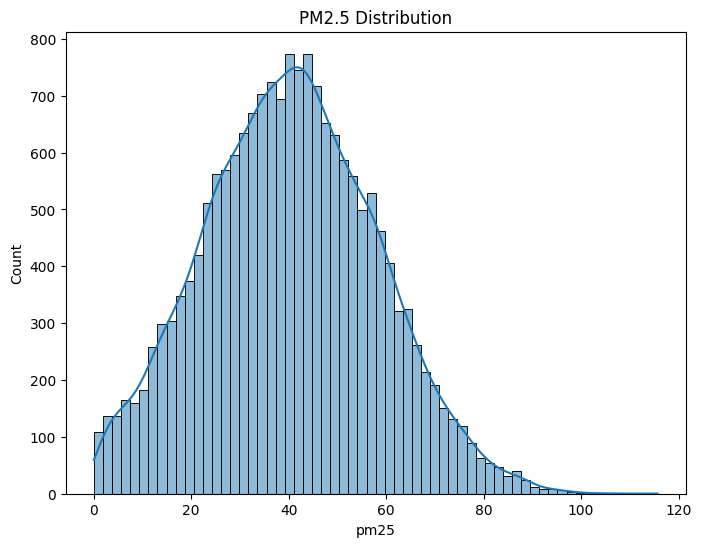

In [23]:
# PM2.5 Distribution
plt.figure(figsize=(8,6))
sns.histplot(df["pm25"], kde=True)
plt.title("PM2.5 Distribution")
plt.show()

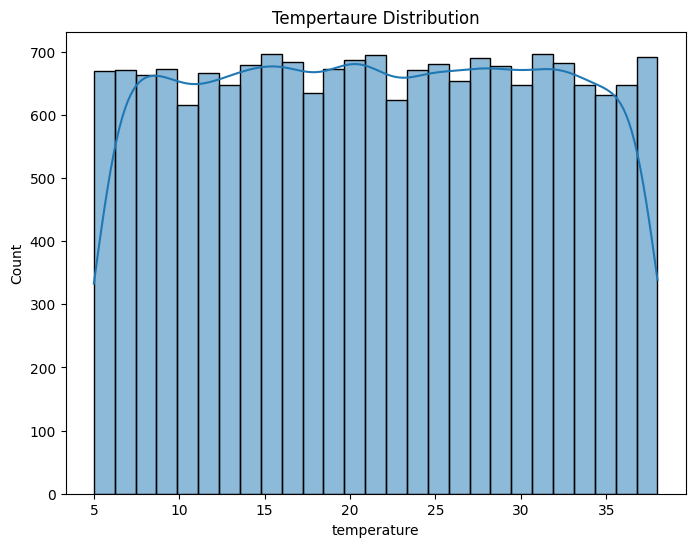

In [24]:
# Temperature Distribution
plt.figure(figsize=(8,6))
sns.histplot(df["temperature"], kde=True)
plt.title("Tempertaure Distribution")
plt.show()

# AQI Distribution analysis

In [25]:
df["aqi"].describe()

count    18000.000000
mean       104.645556
std         25.616070
min         16.000000
25%         87.000000
50%        103.000000
75%        121.000000
max        231.000000
Name: aqi, dtype: float64

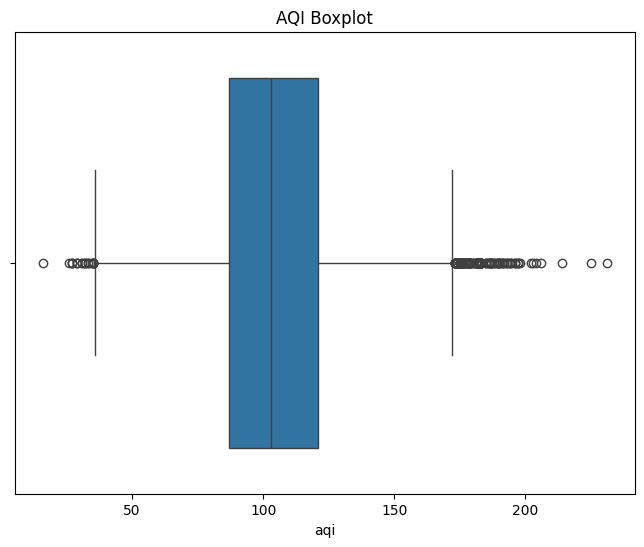

In [26]:
plt.figure(figsize=(8,6))
sns.boxplot(x=df["aqi"])
plt.title("AQI Boxplot")
plt.show()

In [27]:
# City wise pollution analysis
# Average AQI by city
city_aqi = df.groupby("city")["aqi"].mean().sort_values(ascending=False)
city_aqi

city
Doha                107.366667
Lagos               106.616667
Singapore           106.480556
Delhi               106.441667
Karachi             106.300000
Moscow              106.197222
Cape Town           106.158333
Cairo               106.052778
Buenos Aires        105.950000
Paris               105.763889
Zurich              105.722222
Mexico City         105.697222
Osaka               105.691667
New York            105.594444
Dubai               105.530556
Madrid              105.488889
Vancouver           105.444444
Mumbai              105.397222
Bangkok             105.191667
Seoul               105.119444
Helsinki            105.108333
Rome                105.033333
Kuala Lumpur        105.005556
Chicago             104.805556
Riyadh              104.772222
Nairobi             104.747222
Auckland            104.730556
Sydney              104.477778
Los Angeles         104.477778
Berlin              104.422222
Beijing             104.411111
São Paulo           104.319444
Jak

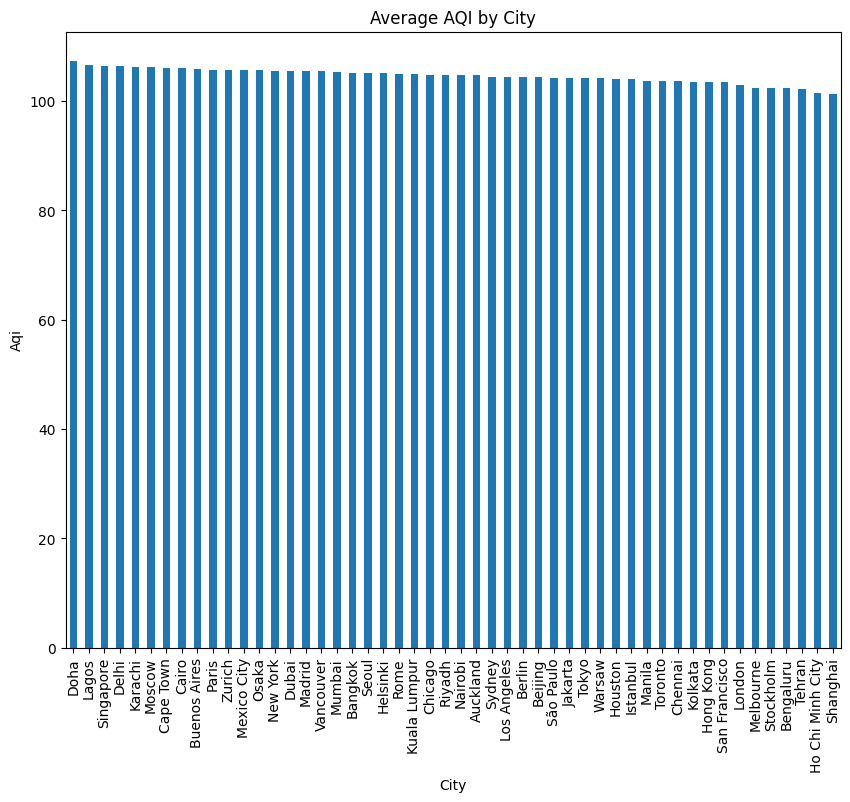

In [28]:
plt.figure(figsize=(10,8))
city_aqi.plot(kind="bar")

plt.title("Average AQI by City")
plt.xlabel("City")
plt.ylabel("Aqi")
plt.show()

In [29]:
# Top 10 polluted cities
top_polluted = city_aqi.head(10)
top_polluted

city
Doha            107.366667
Lagos           106.616667
Singapore       106.480556
Delhi           106.441667
Karachi         106.300000
Moscow          106.197222
Cape Town       106.158333
Cairo           106.052778
Buenos Aires    105.950000
Paris           105.763889
Name: aqi, dtype: float64

## Country Wise Analysis

In [30]:
country_aqi = df.groupby("country")["aqi"].mean().sort_values(ascending=False)
country_aqi

country
Qatar                   107.366667
Nigeria                 106.616667
Singapore               106.480556
Pakistan                106.300000
Russia                  106.197222
South Africa            106.158333
Egypt                   106.052778
Argentina               105.950000
France                  105.763889
Switzerland             105.722222
Mexico                  105.697222
United Arab Emirates    105.530556
Spain                   105.488889
Thailand                105.191667
South Korea             105.119444
Finland                 105.108333
Italy                   105.033333
Malaysia                105.005556
Japan                   104.997222
Saudi Arabia            104.772222
Kenya                   104.747222
New Zealand             104.730556
Canada                  104.544444
United States           104.482778
Germany                 104.422222
Brazil                  104.319444
Indonesia               104.316667
Poland                  104.291667
India       

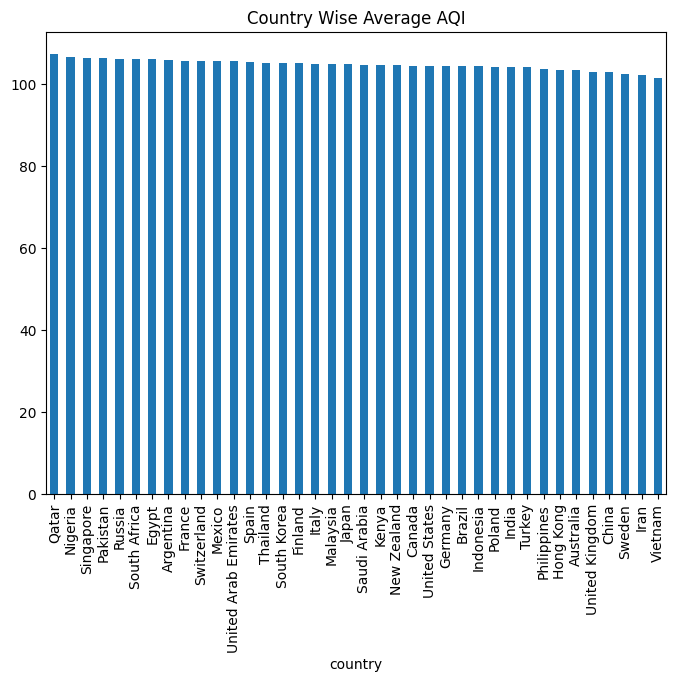

In [31]:
plt.figure(figsize=(8,6))
country_aqi.plot(kind="bar")
plt.title("Country Wise Average AQI")
plt.show()

# Pollutant Trend Analysis

In [32]:
df.head(2)

,timestamp,country,city,latitude,longitude,pm25,pm10,no2,so2,o3,co,aqi,temperature,humidity,wind_speed,hour,day,month,weekday
0,2025-11-04 18:25:17.554219,United States,New York,40.713,-74.006,50.295,108.938,27.998,6.539,52.568,1.096,108,18.504,70.168,3.725,18,4,11,1
1,2025-11-04 19:25:17.554219,United States,New York,40.713,-74.006,32.083,63.043,36.120,4.021,43.536,1.075,90,5.838,80.088,8.969,19,4,11,1


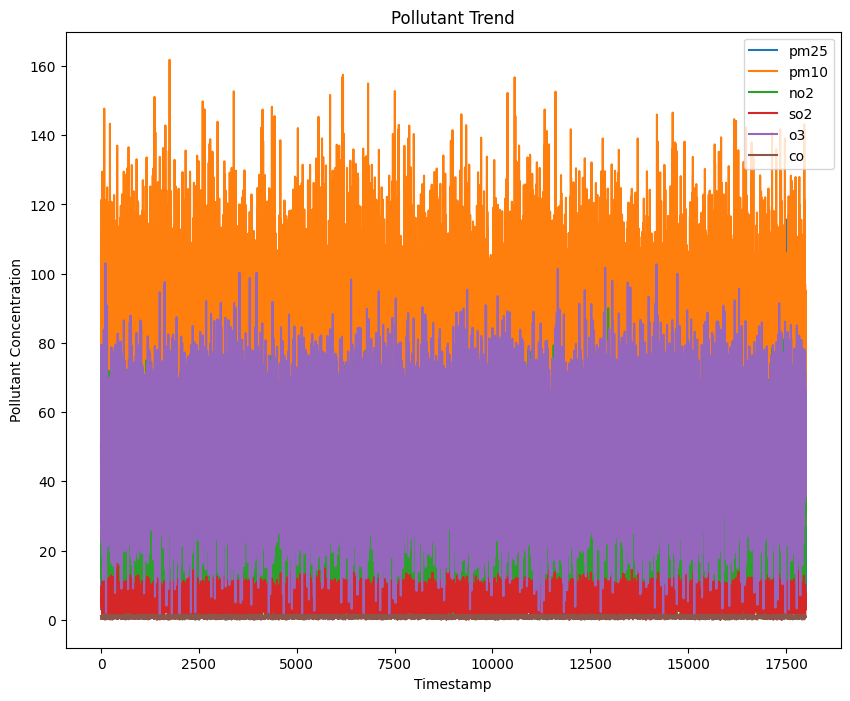

In [35]:
pollutant = ["pm25", "pm10", "no2", "so2", "o3", "co"]

df[pollutant].plot(figsize=(10,8))
plt.title("Pollutant Trend")
plt.xlabel("Timestamp")
plt.ylabel("Pollutant Concentration")
plt.show()